<a href="https://colab.research.google.com/github/wasimnawaz1/NLP_lectures/blob/main/Introduction_to_NLP_(Week_11)_transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CS438  Natural Language Processing (NLP)** (Week 11)
https://github.com/wasimnawaz1/NLP_lectures

### Instructor: Dr. M. Wasim Nawaz (Associate Professor, Artificial Intelligence)
    📞+92-331-4180565  📧 wasim.nawaz@umt.edu.pk

Office: SST 1 - 506
Office Hours (Ramadan): 09:00 am to 10:00 am (Monday to Friday)

Office Hours: 10:00 am to 12:00 pm (Monday to Friday)



### Transformers and Attention

This notebook covers **transformers** architecture and their applications in natural language processing.



### Seq2Seq Architectures and Neural Machine Translation

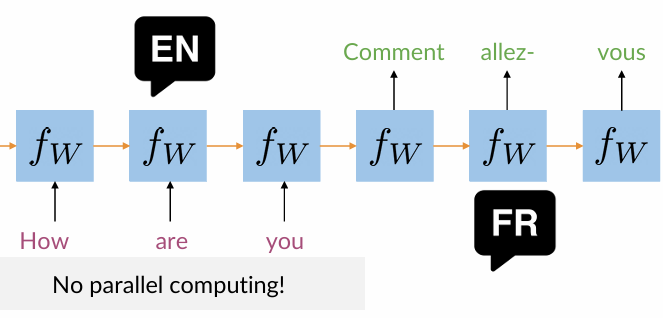


- Seq2Seq architectures use RNNs/GRUs/LSTMs, which process the words/tokens sequentially.
-When sequence is long, we have **information bottleneck** problem - loss of information corresponding to the early time steps.





### Transformer

Transformer is an encoder-decoder architecture.


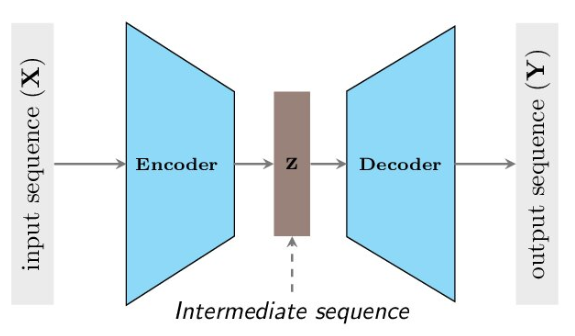



### Transformer Encoder

- Implements self-attention for each item/word/token in the input sequence.
- Nx means repeated N times.

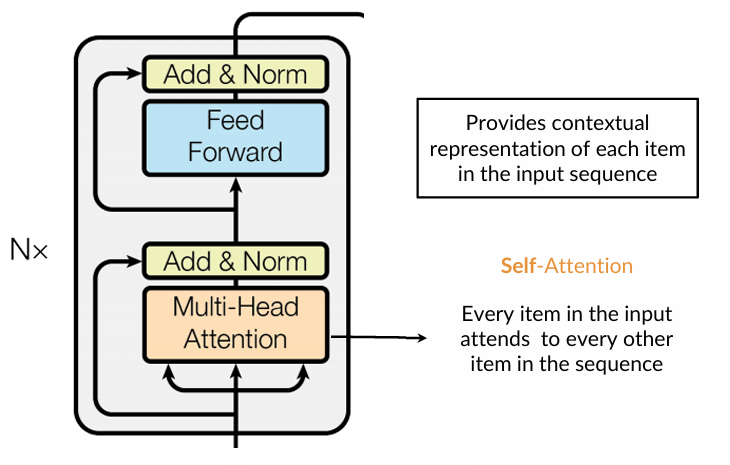

### Transformer Decoder

- Implements masked self-attention: every decoder position attends to previous positions.
- Also, implements encoder-decoder attention: every position from the
decoder attents to the outputs from the encoder.
- Nx means repeated N times.

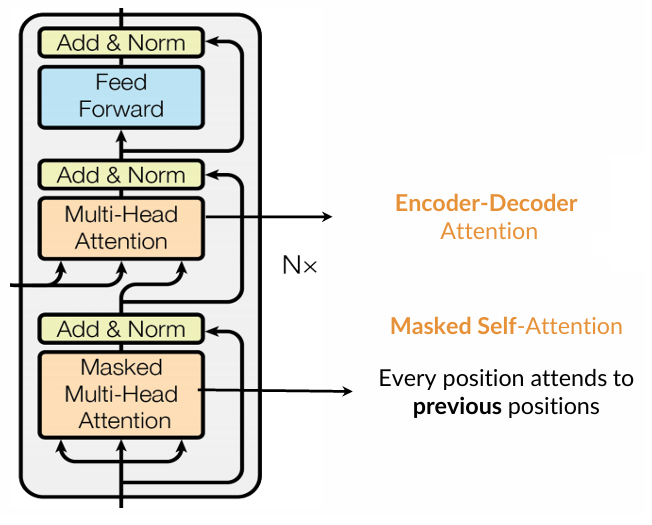

### Full Transformer Architecture

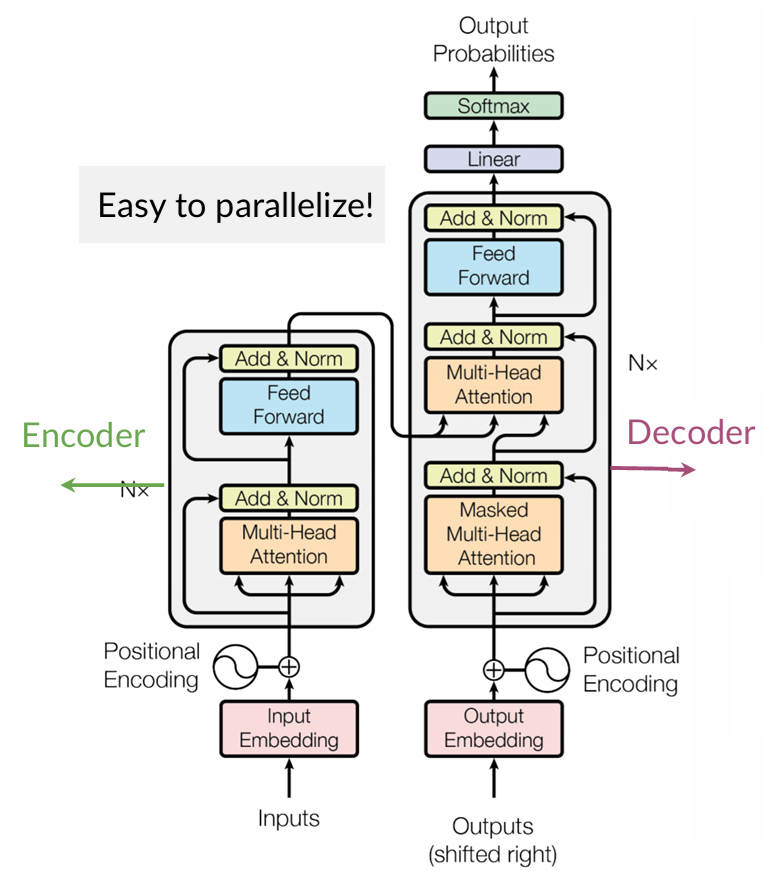

### Transformer Positional Encoding

For position `pos` and embedding dimension `i`:

$$
PE(pos,2i)=\sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

$$
PE(pos,2i+1)=\cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

where:

- `pos` = token position
- `i` = dimension index
- `d_model` = embedding size

---
#### Numerical Example (4-Dimensional Embedding)

For $d_{\text{model}}=4$:
- Dimensions 0 and 1 use denominator $10000^0 = 1$
- Dimensions 2 and 3 use denominator $10000^{2/4}=100$

**Position 0**
$$PE(0,0)=\sin(0)=0$$
$$PE(0,1)=\cos(0)=1$$
$$PE(0,2)=\sin\left(\frac{0}{100}\right)=0$$
$$PE(0,3)=\cos\left(\frac{0}{100}\right)=1$$
$$PE(0)=[0,\;1,\;0,\;1]$$

**Position 1**
$$PE(1,0)=\sin(1)=0.8415$$
$$PE(1,1)=\cos(1)=0.5403$$
$$PE(1,2)=\sin\left(\frac{1}{100}\right)\approx0.0100$$
$$PE(1,3)=\cos\left(\frac{1}{100}\right)\approx0.99995$$
$$PE(1)=[0.8415,\;0.5403,\;0.0100,\;0.99995]$$

**Position 2**
$$PE(2,0)=\sin(2)=0.9093$$
$$PE(2,1)=\cos(2)=-0.4161$$
$$PE(2,2)=\sin\left(\frac{2}{100}\right)\approx0.0200$$
$$PE(2,3)=\cos\left(\frac{2}{100}\right)\approx0.9998$$
$$PE(2)=[0.9093,\;-0.4161,\;0.0200,\;0.9998]$$

The positional encodings for positions 0–2 are as follows:
$$
\begin{bmatrix}
0 & 1 & 0 & 1 \\
0.8415 & 0.5403 & 0.0100 & 0.99995 \\
0.9093 & -0.4161 & 0.0200 & 0.9998
\end{bmatrix}
$$

Each row corresponds to a token position and is added to the token embedding before being fed into the Transformer.


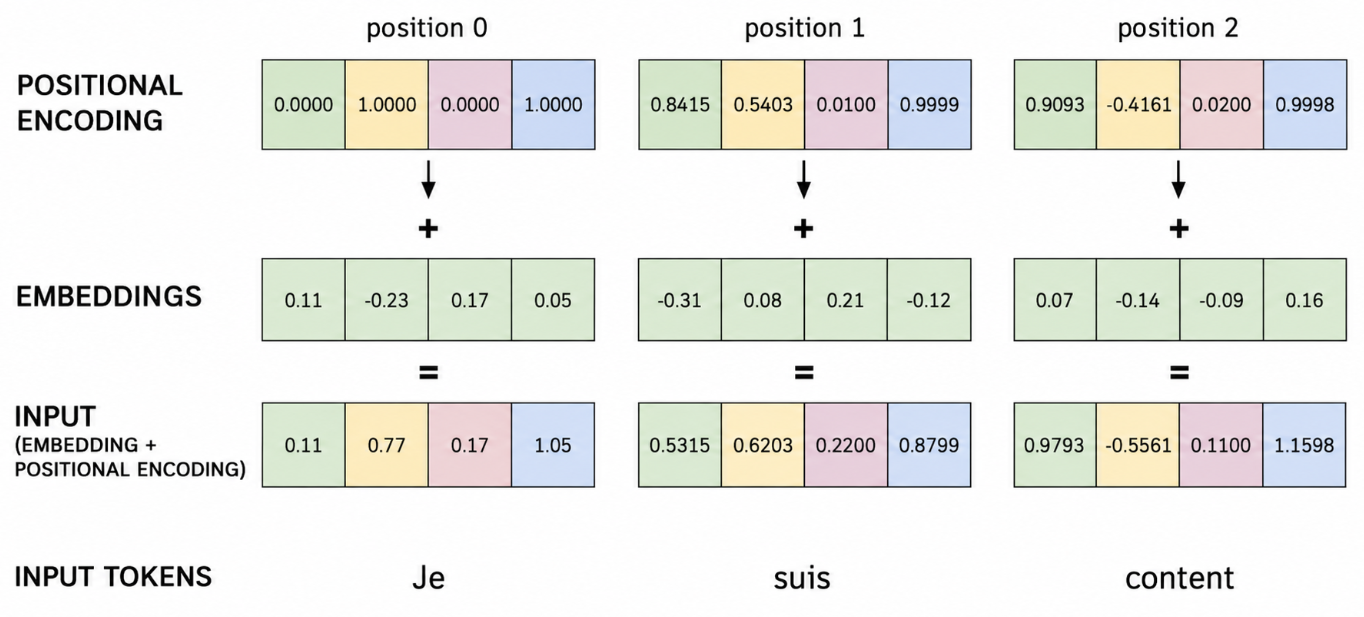

### Query, Key, Value ($QKV$) Framework

The Queries, Keys, and Values framework is fundamental to attention mechanisms for transformer model: [Attention Is All You Need paper by Vaswani et al in 2017](https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf)

**The paper uses Scaled Dot-Product Attention**

$$
\text{Attention}(Q,K,V)
=
\text{softmax}
\left(
\frac{QK^T}{\sqrt{d_k}}
\right)V
$$



Where:
- $Q$: Query matrix ($m × d_k$)
- $K$: Key matrix ($n × d_k$)
- $V$: Value matrix ($n × d_v$)
- $d_k$: Dimension of keys
- $m$: Sequence length of queries from decoder (output length)
- $n$: Sequence length of keys/values (source positions to attend to)

**Why divide by $√d_k$?**
- Prevents dot products from becoming too large
- Keeps softmax gradients stable to improve training stability

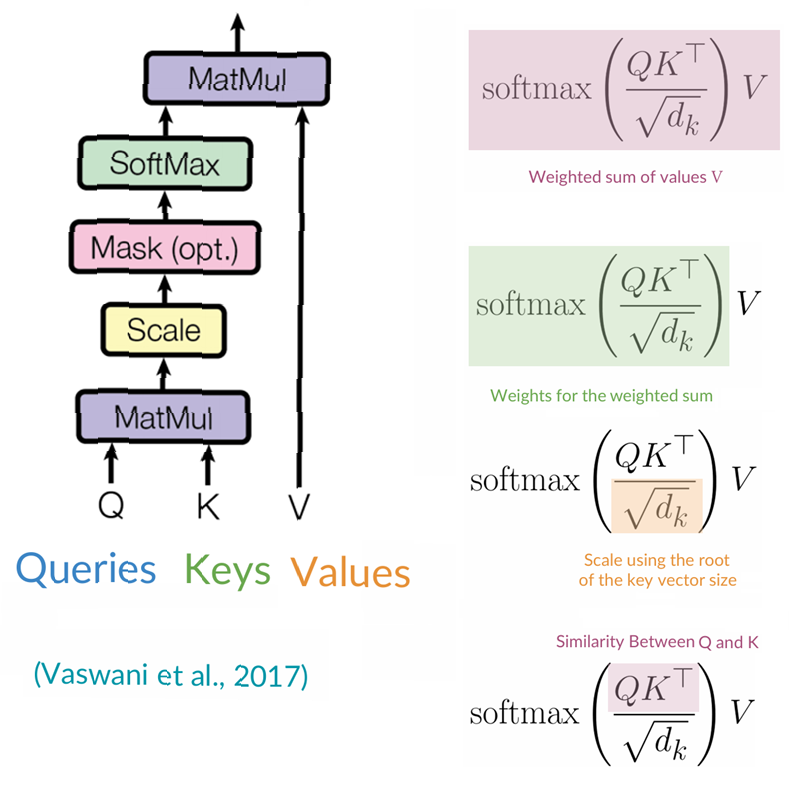

### Attention Computation Process - Numerical Example

#### The Scaled Dot-Product Attention Computation Example
Suppose we have the sentence:

| Word | Key Vector |
|--------|------------|
| It's | k₁ = [0.3, 0.1, 0.2] |
| time | k₂ = [0.2, -0.7, 0.9] |
| for | k₃ = [1.3, 0.3, 0.8] |
| tea | k₄ = [-0.4, 0.6, -1.1] |

Current Query:

```text
q = [0.5, -0.2, 0.8]
```

Key dimension:
```text
d_k = 3
```


---

### Step 1: Compute Similarity Scores (Q · Kᵀ)

#### For "It's"

$$
q \cdot k_1
=
0.5(0.3)+(-0.2)(0.1)+0.8(0.2)
$$

$$
=0.15-0.02+0.16
$$

$$
=0.29
$$

#### For "time"

$$
q \cdot k_2
=
0.5(0.2)+(-0.2)(-0.7)+0.8(0.9)
$$

$$
=0.10+0.14+0.72
$$

$$
=0.96
$$

#### For "for"

$$
q \cdot k_3
=
0.5(1.3)+(-0.2)(0.3)+0.8(0.8)
$$

$$
=0.65-0.06+0.64
$$

$$
=1.23
$$

#### For "tea"

$$
q \cdot k_4
=
0.5(-0.4)+(-0.2)(0.6)+0.8(-1.1)
$$

$$
=-0.20-0.12-0.88
$$

$$
=-1.20
$$

#### Raw Attention Scores

$$
[0.29,\;0.96,\;1.23,\;-1.20]
$$

---

### Step 2: Scale Scores

Now scale the scores by:

$$
\sqrt{d_k}
=
\sqrt{3}
=
1.732
$$

Scaled scores:

$$
\left[
\frac{0.29}{1.732},
\frac{0.96}{1.732},
\frac{1.23}{1.732},
\frac{-1.20}{1.732}
\right]
$$

$$
=
[0.167,\;0.554,\;0.710,\;-0.693]
$$

---

### Step 3: Apply Softmax

Compute exponentials:

$$
e^{0.167}=1.182
$$

$$
e^{0.554}=1.740
$$

$$
e^{0.710}=2.034
$$

$$
e^{-0.693}=0.500
$$

Sum:

$$
Z
=
1.182+1.740+2.034+0.500
=
5.456
$$

Compute probabilities:

$$
\alpha_1
=
\frac{1.182}{5.456}
=
0.217
$$

$$
\alpha_2
=
\frac{1.740}{5.456}
=
0.319
$$

$$
\alpha_3
=
\frac{2.034}{5.456}
=
0.373
$$

$$
\alpha_4
=
\frac{0.500}{5.456}
=
0.092
$$

The query attended to the words with the following importance:

| Word | Attention |
|--------|---------:|
| It's | 21.7% |
| time | 31.9% |
| for | 37.3% |
| tea | 9.2% |

The model therefore retrieves information primarily from **"for"**, followed by **"time"**, then **"It's"**, and very little from **"tea"**.

---

### Step 4: Define Value Vectors

| Word | Value Vector |
|--------|-------------|
| It's | v₁ = [0.5, 0.2] |
| time | v₂ = [0.2, -0.7] |
| for | v₃ = [1.3, 0.3] |
| tea | v₄ = [-0.4, 0.6] |

---

### Step 5: Compute Context Vector

The attention output is:

$$
c
=
0.217v_1
+
0.319v_2
+
0.373v_3
+
0.092v_4
$$

Substituting the value vectors:

$$
c
=
0.217[0.5,0.2]
+
0.319[0.2,-0.7]
+
0.373[1.3,0.3]
+
0.092[-0.4,0.6]
$$

$$
=
[0.1085,0.0434]
+
[0.0638,-0.2233]
+
[0.4849,0.1119]
+
[-0.0368,0.0552]
$$

Adding component-wise:

$$
c
=
[
0.1085+0.0638+0.4849-0.0368,
\;
0.0434-0.2233+0.1119+0.0552
]
$$

$$
=
[0.6204,\;-0.0128]
$$

Therefore, the final context vector is:

$$
\boxed{
c=[0.6204,\;-0.0128]
}
$$

The resulting context vector $c=[0.6204,\;-0.0128]$ is a weighted summary of all value vectors and becomes the output of the attention mechanism that is passed to the decoder for machine translation.

### Transformers vs RNNS

- In RNNs, parallel computing is difficult to implement
- For long sequences in RNNs, there is loss of information
- In RNNs there is the problem of vanishing gradient
- Transformers help with all of the above

### Transformer NLP applications

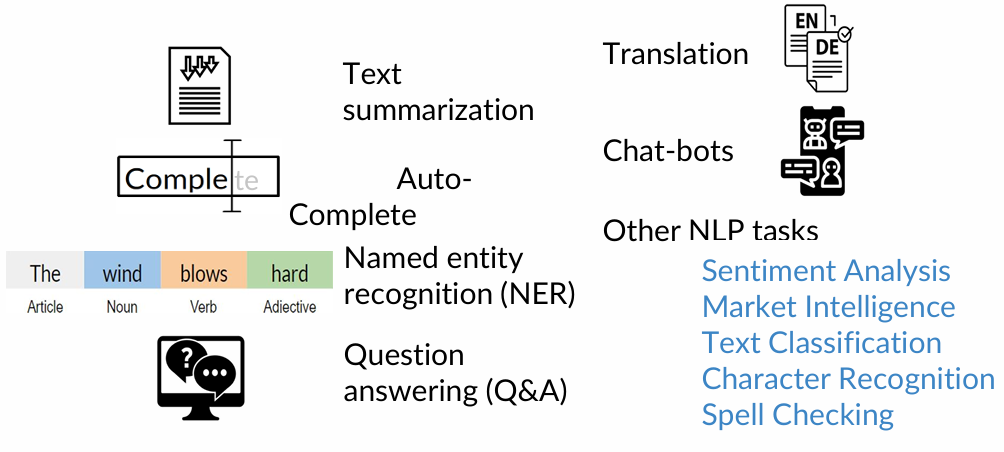

### State of the Art Transformers

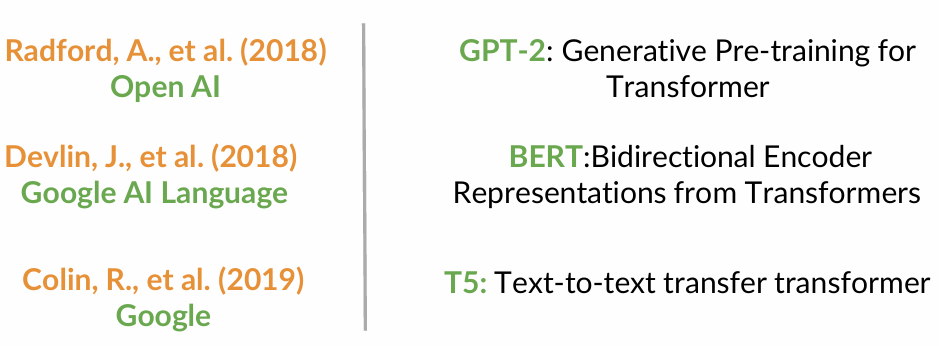

### Queries, Keys and Values

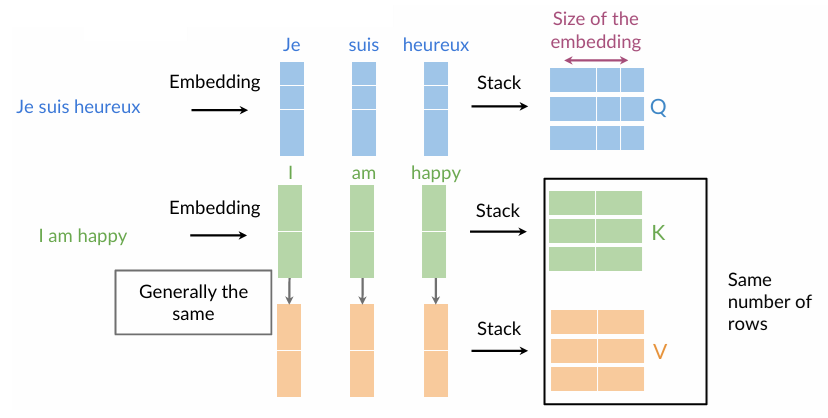

### Attention Math

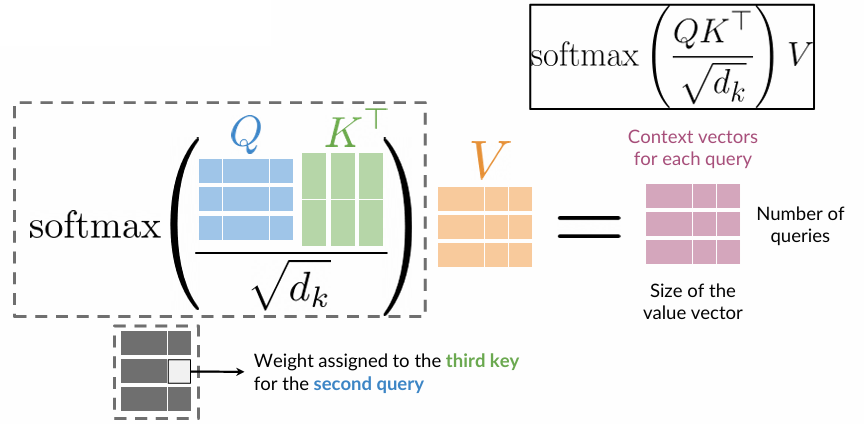

### Encoder-Decoder Attention
Queries from one sentence, keys and values from another

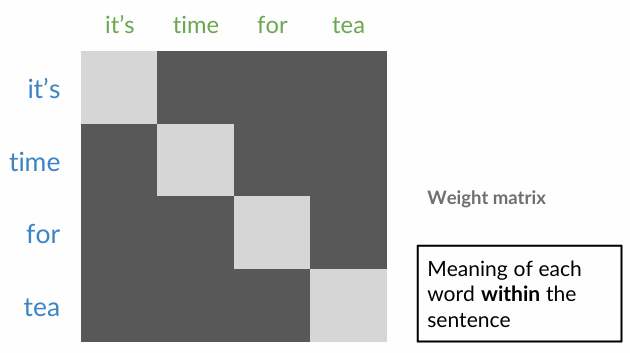

### Masked Self Attention

Queries, keys and values come from the same sentence. Queries don’t attend to future positions.


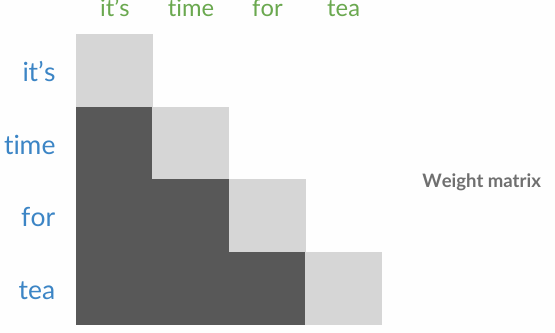

### Masked self-attention math

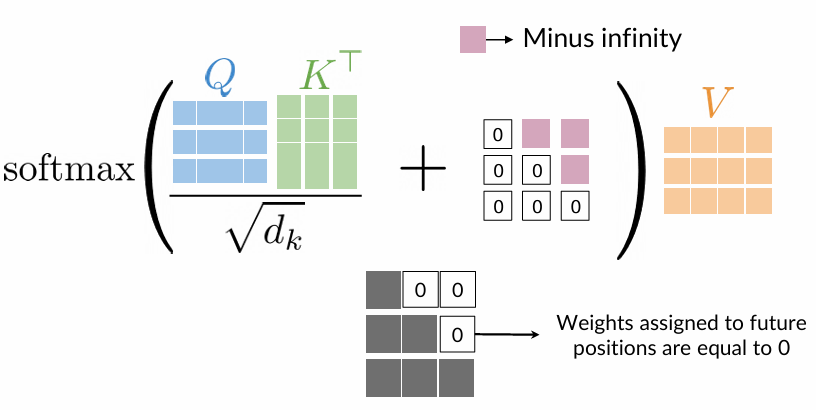

###  Summary of Attention
- There are three main ways of Attention:
   - Encoder/Decoder
   - Self-attention
   - Masked self-attention.
- In self-attention, queries and keys come from the same sentence
- In masked self-attention queries cannot attend to the future


### Multi-Head Attention

Scaled dot product attention applied multiple ($n$) times. $n=3$ in the diagram below.

- Multi-headed models attend to information from different representations
- Parallel computations of multi-head attention can be done



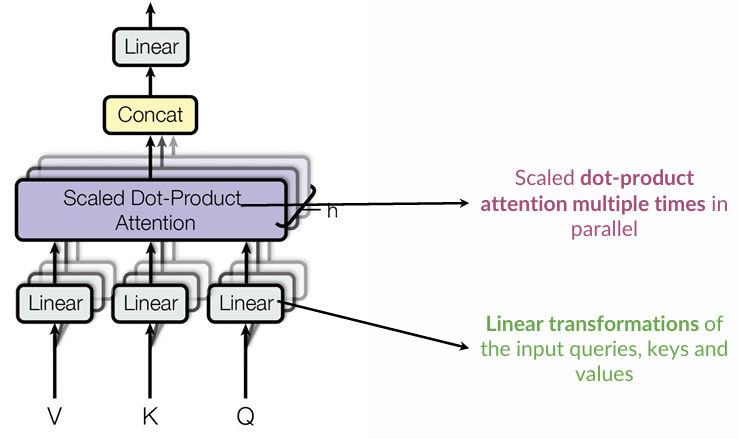


### Multi-Head Attention

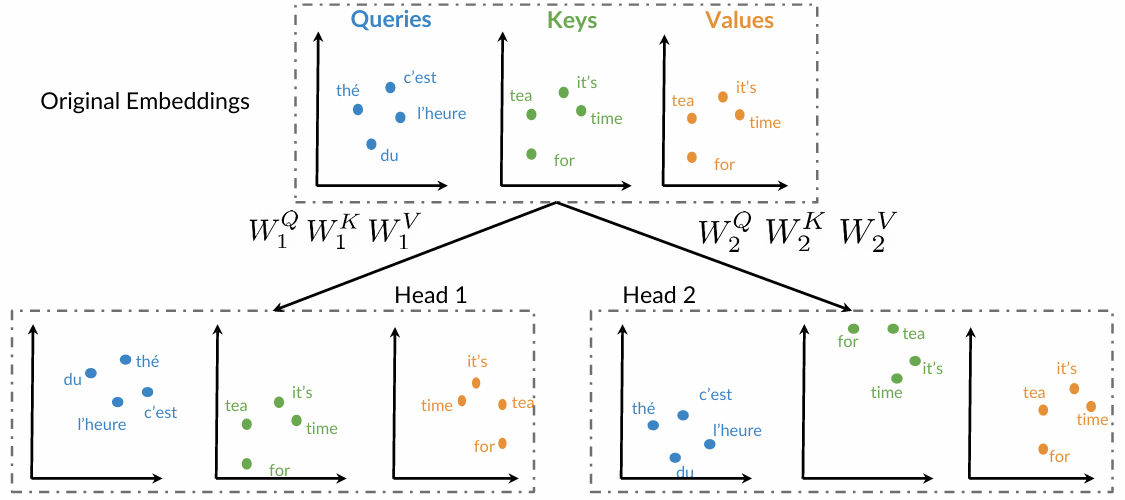

### Multi-Head Attention

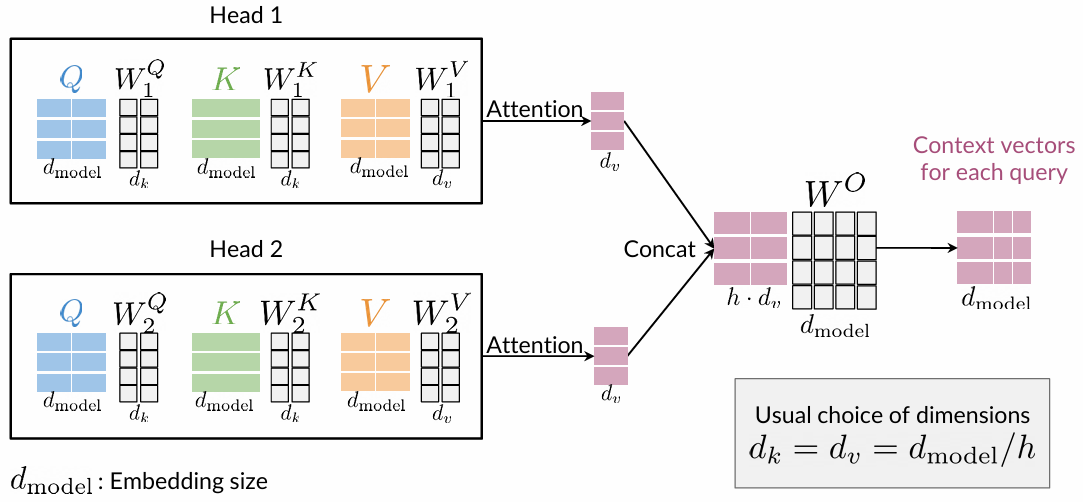

### Application: Transformer Summarizer

Data processing details


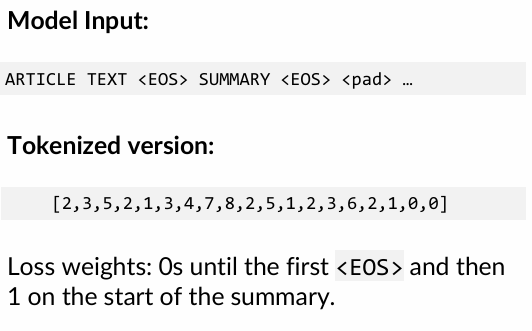






### Application: Transformer Summarizer

Cross entropy loss

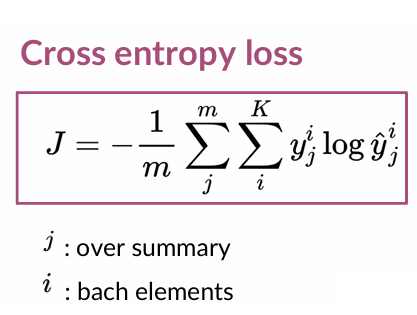

### Application: Transformer Summarizer

Inference with a language model



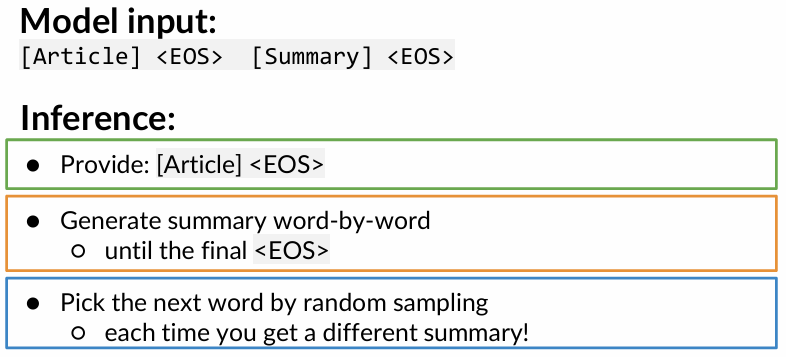




### Summary of Text Summarization
- Transformer decoder summarizes by predicting the next word
- For summarization, a  weighted loss function is optimized
- The transformer uses tokenized versions of the input

### Classical Training vs Transfer Learning

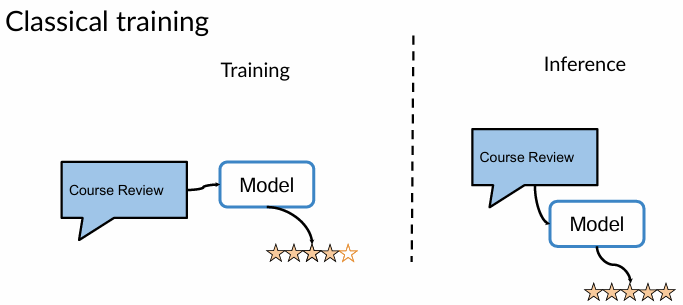

```
```

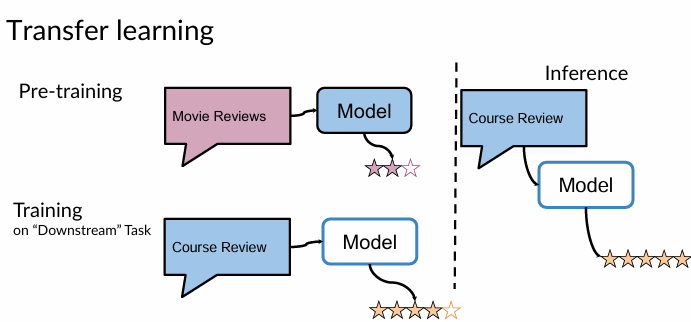


```
```


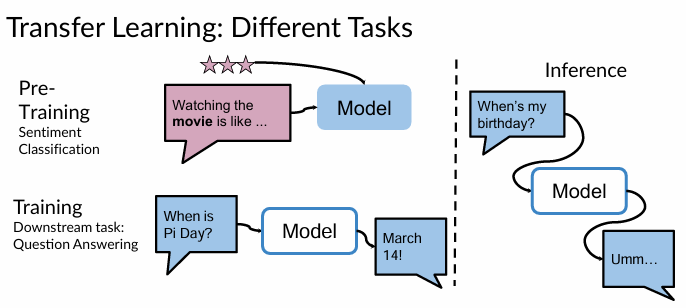

### Transfer Learning options for NLP

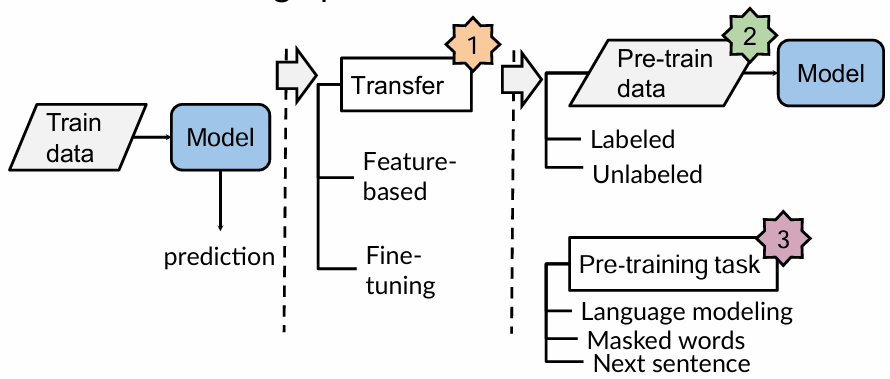

Transfer learning:
- Reduces training time
- Improves predictions
- Small datasets can be used for downstream tasks

### Transferring Embeddings

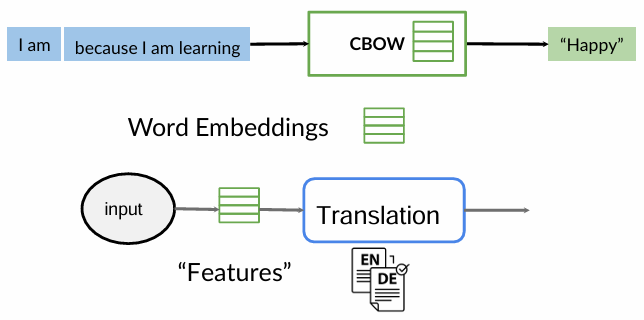


### Feature-based Transfer vs. Fine-Tuning

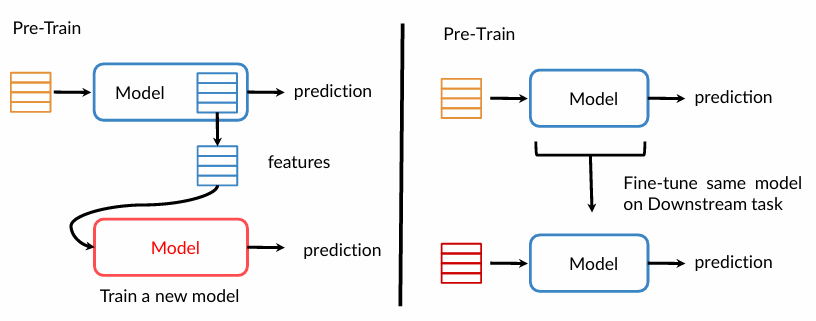

### Fine-tuning: Adding a Layer

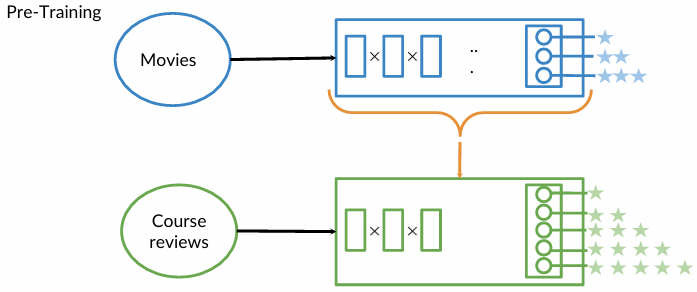

### Data and performance

- Large amount of language data can be used to train bigger models.
- Also, using **self-suprevised** learning, we can create labels from unlabeled data for pre-training models


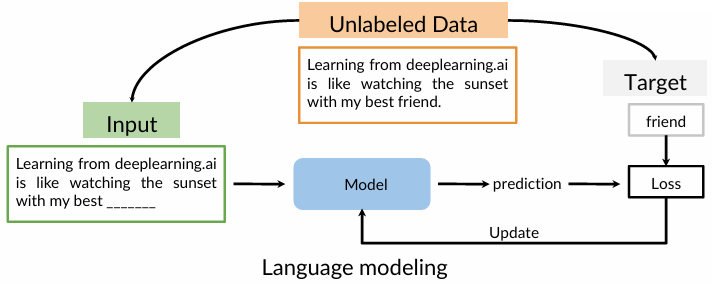

### Fine-tuning a Model for various Downstream Tasks

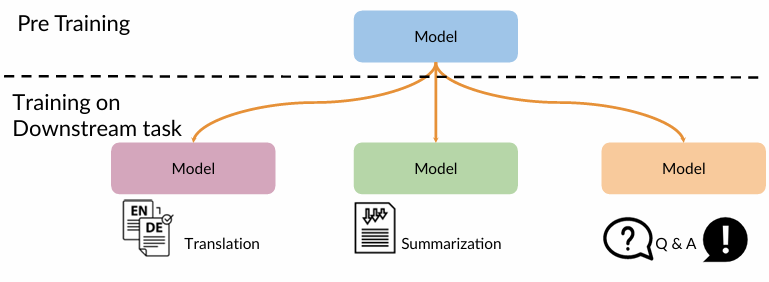

### Transfer Learning Summary

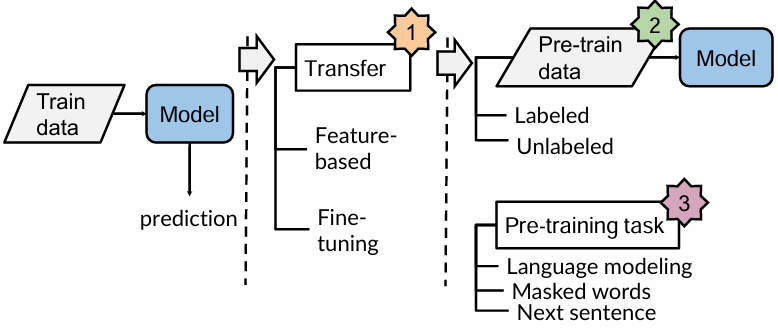

### Bi-directional Context


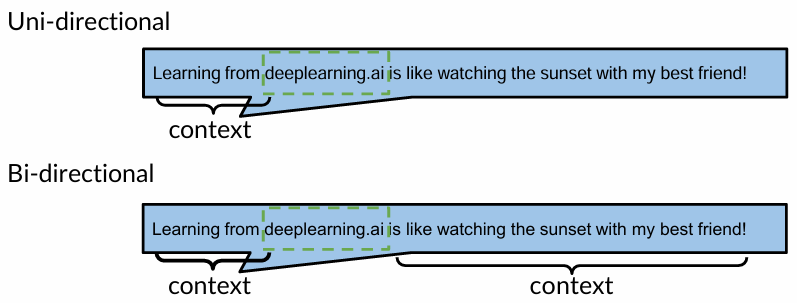

### Bidirectional Encoder Representations from Transformers (BERT)

BERT makes use of transfer learning/pre-training

- A multi layer bidirectional transformer  
- Positional embeddings   
- BERT_base:
   - 12 layers (12 transformer blocks)
   - 12 attentions heads
   - 110 million parameters


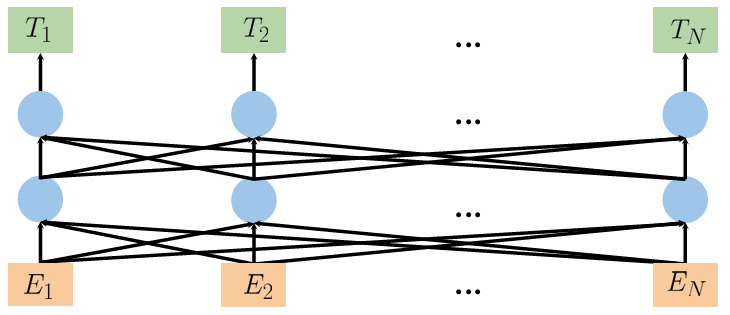

### BERT pre-training
- Pre-training is attained using masked language modeling (MLM) / self-supervised learning.   

**Example**: After school Lukasz does his  homework in the library.

**Masked sentences**

1. After school Lukasz does his _________ in the library.
2. After school ___________ his homework in the _____________.

---

**Strategies for Pre-training**
- Choose 15% of the tokens at random: mask them 80% of the time, replace them with a random token 10% of the time, or keep as is 10%
of the time.  
- There could be multiple masked spans in a sentence.
- Next sentence prediction is also used when pre-training.

### BERT Input, Output, and Objective

**BERT Input**

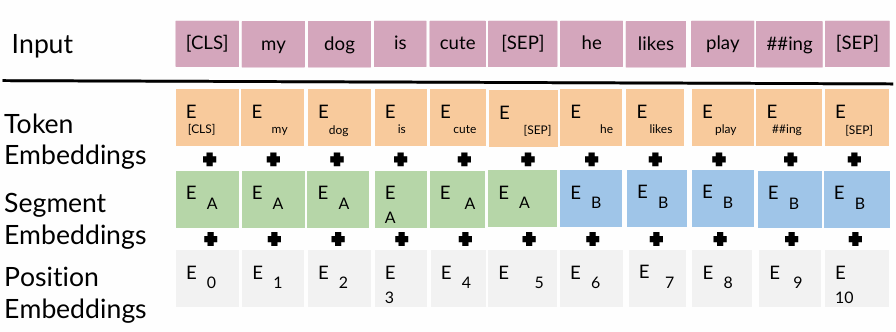

---

**Visualizing the output**



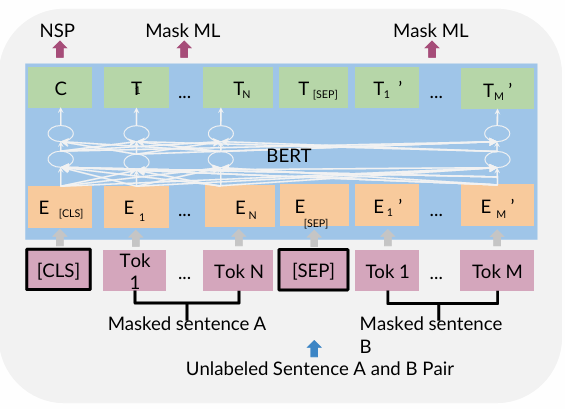


- [CLS]: a special classification symbol added in front of
every input.
- [SEP]: a special separator token.


### BERT Objective

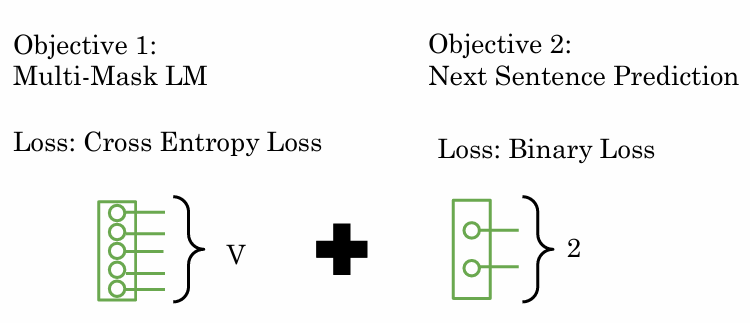

### Fine-tuning BERT

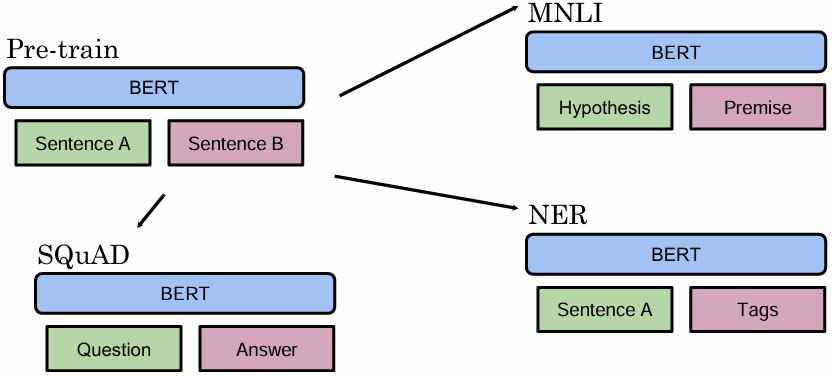

### Fine-tuning BERT

**Inputs**

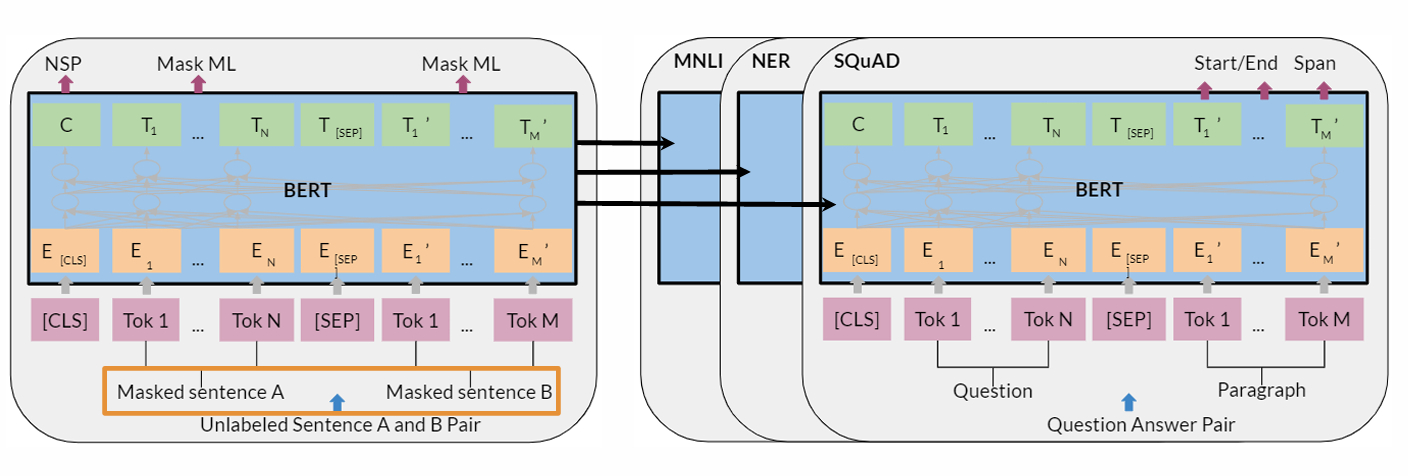

**Summary**

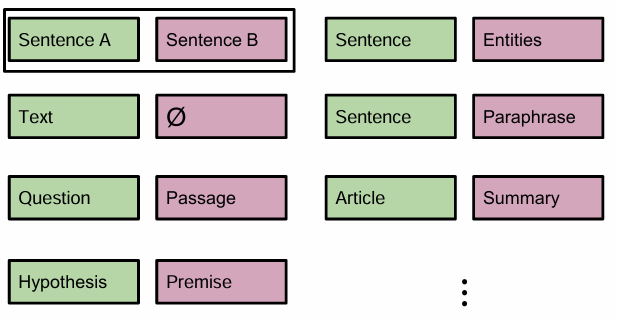

### Implementation of Main Concepts Covered in this Notebook